### **Notebook #1**

# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska
## Hackathon - EDA

### Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm
from collections import Counter


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

# Sigwatch Dataset

## Variables
#### Event identifiers
- **`uid_archive`** – Unique code identifying a campaign event (one or more firms may be targeted).  
- **`date`** – Date when the event was entered into the Sigwatch database (format: YYYY-MM-DD).

---

#### Company information
- **`company`** – Name of the targeted company (could be a parent, subsidiary, or brand).  
- **`company_type`** – Indicates whether the target is a *parent*, *subsidiary*, or *brand*.  
- **`company_parent`** – Name of parent company (if applicable).  
- **`company_parent_country`** – Country where the parent firm is legally headquartered or listed.  
- **`country_corp` / `country_corp_code`** – Country and code of the corporate headquarters.  
- **`isin_corporate_name_official`** – Official listed name of the company.  
- **`isin_corporate_name_cleaned`** – Same name, but with legal suffixes (Ltd, Inc, Plc, etc.) removed.  
- **`bloomberg_ticker`** – Bloomberg ticker symbol of the parent company (if listed).  
- **`isin_1` / `isin_2` / `isin_3`** – ISIN identifiers for the company or its parent, if available.

---

#### NGO and campaign characteristics
- **`sentiment`** – Tone of NGO communication toward the company:  
  - `-2` very negative, `-1` negative, `0` neutral, `+1` positive, `+2` very positive.  
- **`prominence`** – Visibility of the company in the NGO message:  
  - `+4` headline mention, `+3` first paragraph, `+2` elsewhere, `+1` in attached report.  
- **`partnership`** – Equals `1` if the company is working in partnership with the NGO.  

---

#### Issue and location variables
- **`issue_code_1–3` / `issue_name_1–3`** – Campaign topics, selected from 900+ predefined categories (e.g., *GMOs in food*, *Climate change*, *Herbicide impact*).  
- **`active_country_1–6`** – Country or countries where NGO action is taking place.  
- **`target_country_1–6`** – Country or countries targeted by the NGO (may overlap with active countries).

---

#### NGO information
- **`ngo_code_1–5` / `ngo_name_1–5`** – Code and name(s) of the NGO(s) involved in the event.  
- **`ngo_country_code` / `ngo_country`** – Headquarters country of the NGO or its branch.  
- **`ngo_power`** – Scale of NGO influence, from *local* (lowest) to *global* (highest).

---

#### Industry classification
- **`corp_industry_sector_code_1–3`** – Codes for the firm’s industrial activities (Sigwatch-specific, not standard NAICS/SIC).  
- **`corp_industry_sector_1–3`** – Text description of those sectors.  
- **`industry_sector_code_1–4`** – Codes describing the sector affected by the specific campaign.  
- **`industry_sector_1–4`** – Text description of those campaign-related sectors.

---

#### Sources and text
- **`report`** – Text summary of the campaign event, written by Sigwatch.  
- **`link_1–5`** – URLs linking to original NGO statements or reports.


In [2]:
years = range(2010, 2019)
sigwatch_data = {}

for year in years:
    df = pd.read_stata(f"sigwatch_data/{year}_data_sigwatch.dta")
    sigwatch_data[year] = df


In [3]:
years = range(2010, 2019)

for year in years:
    print(year, "dimension:", sigwatch_data[year].shape)

2010 dimension: (3439, 94)
2011 dimension: (6030, 94)
2012 dimension: (7366, 94)
2013 dimension: (8488, 94)
2014 dimension: (8761, 94)
2015 dimension: (8547, 94)
2016 dimension: (8582, 94)
2017 dimension: (9307, 94)
2018 dimension: (12574, 94)


In [4]:
sigwatch_data[2010].columns

Index(['uid_archive', 'date', 'company_code', 'company', 'company_type',
       'company_parent_code', 'company_parent', 'company_parent_country',
       'sentiment', 'prominence', 'partnership', 'issue_code1', 'issue_name1',
       'issue_code2', 'issue_name2', 'issue_code3', 'issue_name3',
       'active_country_code1', 'active_country1', 'active_country_code2',
       'active_country2', 'active_country_code3', 'active_country3',
       'active_country_code4', 'active_country4', 'active_country_code5',
       'active_country5', 'active_country_code6', 'active_country6',
       'target_country_code1', 'target_country1', 'target_country_code2',
       'target_country2', 'target_country_code3', 'target_country3',
       'target_country_code4', 'target_country4', 'target_country_code5',
       'target_country5', 'target_country_code6', 'target_country6',
       'ngo_code1', 'ngo_name1', 'ngo_power1', 'ngo_country_code1',
       'ngo_country1', 'ngo_code2', 'ngo_name2', 'ngo_power2',
    

In [5]:
sigwatch_data[2010].head(5)

,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,partnership,issue_code1,issue_name1,issue_code2,issue_name2,issue_code3,issue_name3,active_country_code1,active_country1,active_country_code2,active_country2,active_country_code3,active_country3,active_country_code4,active_country4,active_country_code5,active_country5,active_country_code6,active_country6,target_country_code1,target_country1,target_country_code2,target_country2,target_country_code3,target_country3,target_country_code4,target_country4,target_country_code5,target_country5,target_country_code6,target_country6,ngo_code1,ngo_name1,ngo_power1,ngo_country_code1,ngo_country1,ngo_code2,ngo_name2,ngo_power2,ngo_country_code2,ngo_country2,ngo_code3,ngo_name3,ngo_power3,ngo_country_code3,ngo_country3,ngo_code4,ngo_name4,ngo_power4,ngo_country_code4,ngo_country4,ngo_code5,ngo_name5,ngo_power5,ngo_country_code5,ngo_country5,country_code_corp,country_corp,corp_industry_sector_code1,corp_industry_sector1,corp_industry_sector_code2,corp_industry_sector2,corp_industry_sector_code3,corp_industry_sector3,isin_corporate_name_official,isin_corporate_name_cleaned,bloomberg_ticker,isin_1,isin_2,isin_3,industry_sector_code1,industry_sector1,industry_sector_code2,industry_sector2,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,36273,2010-10-01,67,Tesoro,Parent,67,Tesoro,US,-1,2,0,3443,Climate change - intl/govt action on GHG emissions,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1327,Oil,NaN,,NaN,,Tesoro Corp,Tesoro,TSO,US8816091016,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influential voice to calls for Californian voters in to reject the ballot measure Prop 23 in November, which aims to repeal the state's carbon emissions and renewable energy law. It said the measure is a bad deal for the state, would damage the economy and the environment, and simply serves the interests of the oil industry. See",http://www.consumersunion.org/pub/core_other_issues/016931.html,,,,NaN
1,36273,2010-10-01,103,Valero Energy Corporation,Parent,103,Valero Energy Corporation,US,-1,2,0,3443,Climate change - intl/govt action on GHG emissions,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1286,Chemicals,1315.0,Energy,1327.0,Oil,Valero Energy Corp,Valero Energy,VLO,US91913Y1001,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influential voice to calls for Californian voters in to reject the ballot measure Prop 23 in November, which aims to repeal the state's carbon emissions and renewable energy law. It said the measure is a bad deal for the state, would damage the economy and the environment, and simply serves the interests of the oil industry. See",http://www.consumersunion.org/pub/core_other_issues/016931.html,,,,NaN
2,36247,2010-01-06,4,Pfizer,Parent,4,Pfizer,US,-1,2,0,3375,Drug safety,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,628,Medwatcher Japan,1.0,392,Japan,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1340,Pharmaceuticals,NaN,,NaN,,Pfizer Inc,Pfizer,PFE,US7170811035,,,1340.0,Pharmaceuticals,NaN,,NaN,,NaN,NaN,"<p>In Japan, Medwatcher/Yakugai demanded Pfizer again revise the package insert supplied with its Champix smoking cessation treatment to warn users of possible neuropsychiatric symptoms including changes in behavior, agitation, depressed mood, suicidal thoughts and suicidal behavior. Medwatcher claimed the new Japanese wording on the warning section implies these symptoms result from the smoking cessation itself. See</p

## Dataset Exploration

In [6]:
# Combine all years into one DataFrame
combined = pd.concat(sigwatch_data.values(), ignore_index=True)
print("Combined shape:", combined.shape)

display(combined.head())

Combined shape: (73094, 94)


,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,partnership,issue_code1,issue_name1,issue_code2,issue_name2,issue_code3,issue_name3,active_country_code1,active_country1,active_country_code2,active_country2,active_country_code3,active_country3,active_country_code4,active_country4,active_country_code5,active_country5,active_country_code6,active_country6,target_country_code1,target_country1,target_country_code2,target_country2,target_country_code3,target_country3,target_country_code4,target_country4,target_country_code5,target_country5,target_country_code6,target_country6,ngo_code1,ngo_name1,ngo_power1,ngo_country_code1,ngo_country1,ngo_code2,ngo_name2,ngo_power2,ngo_country_code2,ngo_country2,ngo_code3,ngo_name3,ngo_power3,ngo_country_code3,ngo_country3,ngo_code4,ngo_name4,ngo_power4,ngo_country_code4,ngo_country4,ngo_code5,ngo_name5,ngo_power5,ngo_country_code5,ngo_country5,country_code_corp,country_corp,corp_industry_sector_code1,corp_industry_sector1,corp_industry_sector_code2,corp_industry_sector2,corp_industry_sector_code3,corp_industry_sector3,isin_corporate_name_official,isin_corporate_name_cleaned,bloomberg_ticker,isin_1,isin_2,isin_3,industry_sector_code1,industry_sector1,industry_sector_code2,industry_sector2,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,36273,2010-10-01,67,Tesoro,Parent,67,Tesoro,US,-1,2,0,3443,Climate change - intl/govt action on GHG emissions,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1327.0,Oil,NaN,,NaN,,Tesoro Corp,Tesoro,TSO,US8816091016,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influential voice to calls for Californian voters in to reject the ballot measure Prop 23 in November, which aims to repeal the state's carbon emissions and renewable energy law. It said the measure is a bad deal for the state, would damage the economy and the environment, and simply serves the interests of the oil industry. See",http://www.consumersunion.org/pub/core_other_issues/016931.html,,,,NaN
1,36273,2010-10-01,103,Valero Energy Corporation,Parent,103,Valero Energy Corporation,US,-1,2,0,3443,Climate change - intl/govt action on GHG emissions,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1286.0,Chemicals,1315.0,Energy,1327.0,Oil,Valero Energy Corp,Valero Energy,VLO,US91913Y1001,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influential voice to calls for Californian voters in to reject the ballot measure Prop 23 in November, which aims to repeal the state's carbon emissions and renewable energy law. It said the measure is a bad deal for the state, would damage the economy and the environment, and simply serves the interests of the oil industry. See",http://www.consumersunion.org/pub/core_other_issues/016931.html,,,,NaN
2,36247,2010-01-06,4,Pfizer,Parent,4,Pfizer,US,-1,2,0,3375,Drug safety,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,628,Medwatcher Japan,1.0,392,Japan,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1340.0,Pharmaceuticals,NaN,,NaN,,Pfizer Inc,Pfizer,PFE,US7170811035,,,1340.0,Pharmaceuticals,NaN,,NaN,,NaN,NaN,"<p>In Japan, Medwatcher/Yakugai demanded Pfizer again revise the package insert supplied with its Champix smoking cessation treatment to warn users of possible neuropsychiatric symptoms including changes in behavior, agitation, depressed mood, suicidal thoughts and suicidal behavior. Medwatcher claimed the new Japanese wording on the warning section implies these symptoms result from the smoking cessation itself. 

### Missing Values

In [7]:
# Nulls table
nulls = combined.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(combined) * 100).round(2)
null_df = pd.DataFrame({"missing_count": nulls, "missing_pct": nulls_pct})

# Show top 30 missing columns
display(null_df.head(30))

,missing_count,missing_pct
industry_sector4,73094,100.00
industry_sector_code4,73094,100.00
link5,73094,100.00
active_country_code6,73083,99.98
active_country_code5,73028,99.91
active_country_code4,72775,99.56
target_country_code6,72252,98.85
active_country_code3,71972,98.46
ngo_code5,71902,98.37
ngo_power5,71902,98.37


There are numerous columns with high percentage of missing values which we'll target as the Data Exploration progresses.

### Unique Issues by country

In [8]:
# Unique issues per Active Country
country_issue_counts = (
    combined
      .assign(active_country1=combined["active_country1"].fillna("Unknown"))
      .groupby("active_country1")["issue_name1"]
      .nunique()
      .sort_values(ascending=False)
)

# Top-20 table
display(country_issue_counts.head(20).to_frame(name="unique_issues_per_country"))


,unique_issues_per_country
active_country1,
US,410
USA,369
UK,351
Germany,294
Netherlands,231
France,194
Spain,191
Denmark,165
Norway,161


NGOs operating in **the USA and the UK** cover the **widest range of campaign topics**, followed by those in Germany and the Netherlands.

C:\Users\lasko\AppData\Local\Temp\ipykernel_33508\2582197269.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


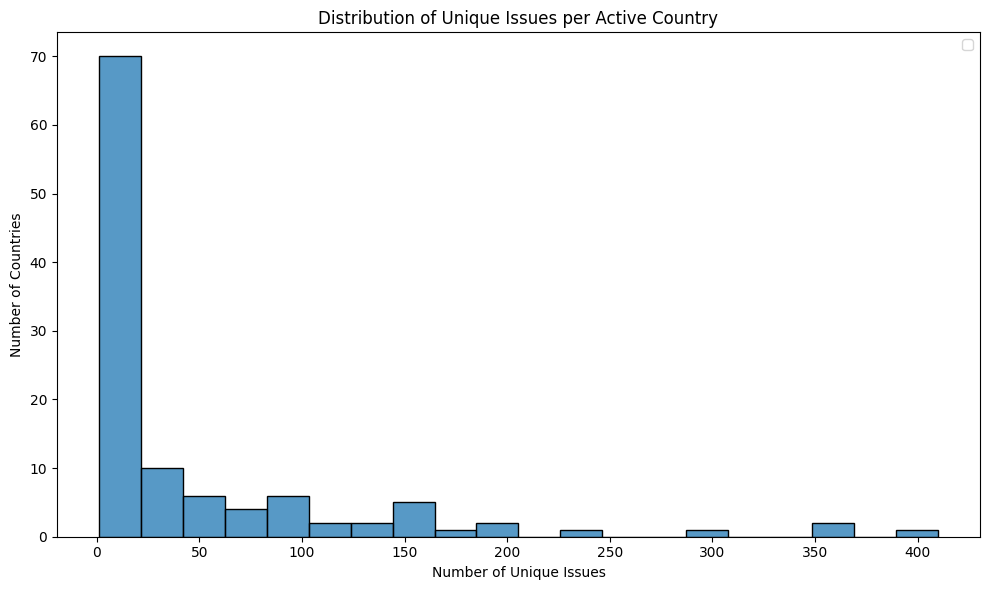

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(country_issue_counts, bins=20, kde=False)
plt.title("Distribution of Unique Issues per Active Country")
plt.xlabel("Number of Unique Issues")
plt.ylabel("Number of Countries")
plt.legend()
plt.tight_layout()
plt.show()

In most countries where NGOs operate, **campaign topics tend to fall within a narrower range**.

### NGO's Country vs Country of the targeted Company (Domenstic vs. Foreign)

In [10]:
# Compare NGO country vs company country (home vs foreign)
combined["home_target"] = np.where(
    combined["ngo_country1"] == combined["country_corp"],
    "Domestic Target",
    "Foreign Target"
)
home_foreign = combined["home_target"].value_counts(normalize=True) * 100
display(home_foreign.to_frame(name="% of campaigns"))


,% of campaigns
home_target,
Domestic Target,56.758421
Foreign Target,43.241579


C:\Users\lasko\AppData\Local\Temp\ipykernel_33508\1045232896.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=home_foreign.index, y=home_foreign.values, palette="Set2")


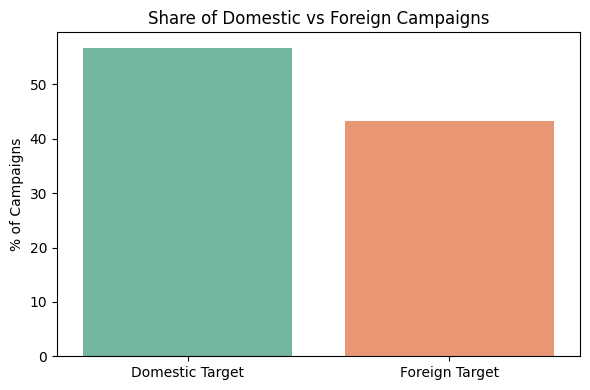

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(x=home_foreign.index, y=home_foreign.values, palette="Set2")
plt.title("Share of Domestic vs Foreign Campaigns")
plt.ylabel("% of Campaigns")
plt.xlabel("")
plt.tight_layout()
plt.show()


**Most campaigns** are carried out by NGOs **headquartered in the same country** as the companies they target.

### NGO vs Number of unique Campaign Topics

In [12]:
# Unique issues per NGO
ngo_issue_counts = (
    combined
      .assign(ngo_name1=combined["ngo_name1"].fillna("Unknown"))
      .groupby("ngo_name1")["issue_name1"]
      .nunique()
      .sort_values(ascending=False)
)

# Top-20 table
display(ngo_issue_counts.head(20).to_frame(name="unique_issues_per_ngo"))

,unique_issues_per_ngo
ngo_name1,
Friends of the Earth U.S. / FoE U.S.,79
Greenpeace USA,69
Center for Biological Diversity CBD,68
Sierra Club U.S.A.,68
Greenpeace Germany,65
Greenpeace UK,62
Natural Resources Defense Council NRDC,61
Greenpeace Spain,56
Food & Water Watch FWW,55


The NGOs with the **broadest variety of campaign topics** are:
- Friends of the Earth U.S. / FoE U.S.
- Greenpeace USA	
- Sierra Club U.S.A.
- Center for Biological Diversity CBD
- Greenpeace Germany
- Greenpeace UK

Overall, it is evident that **Greenpeace organizations across different countries** tend to cover **a particularly wide range of campaign topics.**

C:\Users\lasko\AppData\Local\Temp\ipykernel_33508\4132975838.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


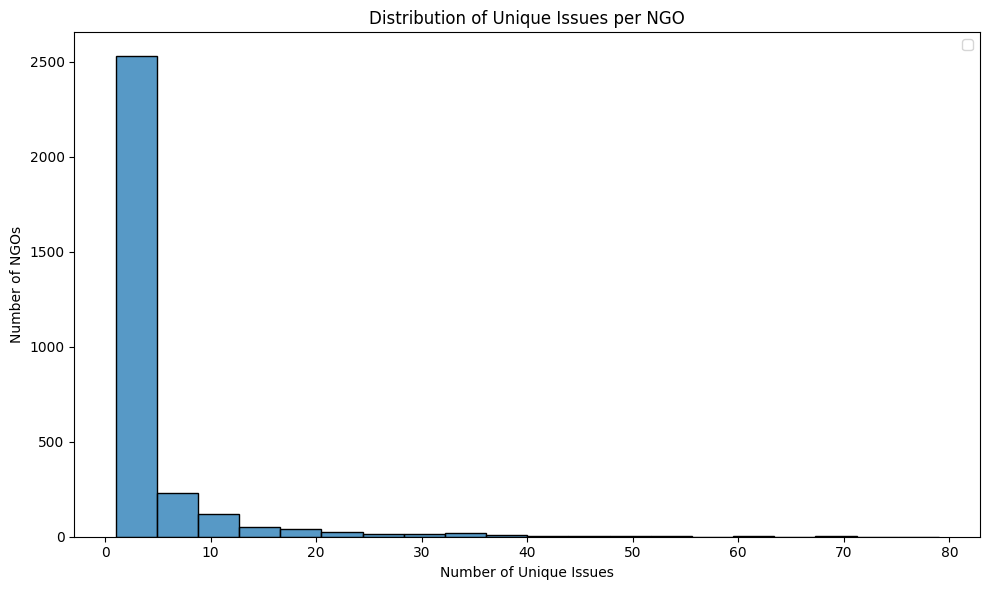

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(ngo_issue_counts, bins=20, kde=False)
plt.title("Distribution of Unique Issues per NGO")
plt.xlabel("Number of Unique Issues")
plt.ylabel("Number of NGOs")
plt.legend()
plt.tight_layout()
plt.show()

The graph shows that **most NGOs focus on specific campaign topics**, while only a few address a broad range of issues.

### Campaign frequency by year

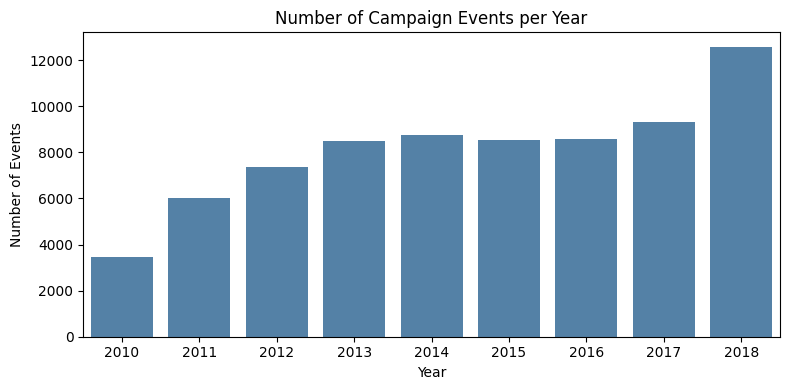

In [14]:
# Campaign frequency by year
combined["year"] = pd.to_datetime(combined["date"], errors="coerce").dt.year
campaigns_by_year = combined["year"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=campaigns_by_year.index, y=campaigns_by_year.values, color="steelblue")
plt.title("Number of Campaign Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()


- We observe an overall **upward trend in the total number of campaign events** over time.
- This indicates **growing NGO activism** over the years.
- A sharp **spike is visible in 2018**, with more than 12,000 events, what could reflect **increased mobilization** or **a response to global issues gaining traction**.

### Distribution of sentiment scores

C:\Users\lasko\AppData\Local\Temp\ipykernel_33508\3876727376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index.astype(str), y=sentiment_counts.values, palette="coolwarm")


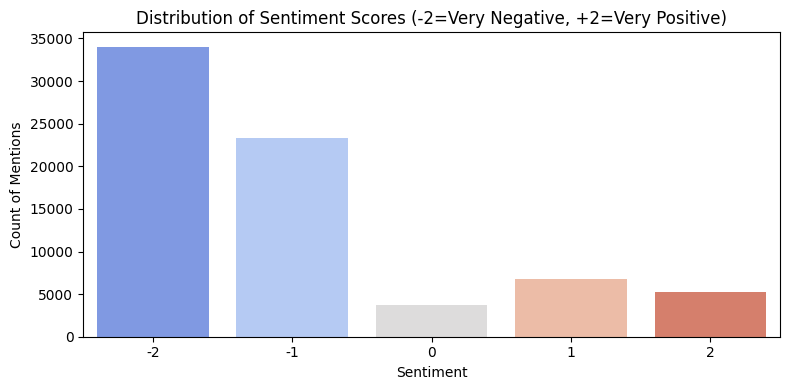

In [15]:
# Distribution of sentiment scores
sentiment_counts = combined["sentiment"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=sentiment_counts.index.astype(str), y=sentiment_counts.values, palette="coolwarm")
plt.title("Distribution of Sentiment Scores (-2=Very Negative, +2=Very Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count of Mentions")
plt.tight_layout()
plt.show()


- The **majority of mentions have negative sentiment**, with a strong concentration at very negative, what may reflect **public criticism, dissatisfaction or controversy** surrounding the topic being analyzed.
- Positive sentiments occur far less frequently, indicating that **overall discussion is predominantly negative**.
- **Neutral sentiment is relatively rare**, suggesting that **most mentions express a clear opinion** rather than neutrality.


### Most often targeted Parent Companies

In [16]:
# Top targeted parent companies
top_companies = combined["company_parent"].value_counts().head(20)
display(top_companies.to_frame(name="num_events"))

,num_events
company_parent,
Monsanto,1025
Shell (Royal Dutch Shell),821
TransCanada,704
Nestle,702
Walmart,594
BP,590
Unilever,572
ExxonMobil,542
Coca-Cola Company,511


- **Monsanto** stands out as the **most frequently targeted** parent company, with over 1,000 campaign events. The sustained NGO focus is likely due to **controversies around agriculture, GMOs, and environmental impact.**
- **Shell (Royal Dutch Shell), BP, and ExxonMobil** are also among the top targets, reflecting strong NGO **attention on fossil fuel and energy companies** due to their roles in **climate change and environmental degradation**.
- Consumer goods giants like **Nestlé, Unilever, and Coca-Cola** also feature prominently, indicating growing concern about **plastic pollution, labor practices, and sustainability issues** in global supply chains.

### Mostly targeted Sectors

In [17]:
# Top sectors targeted
top_sectors = combined["corp_industry_sector1"].value_counts().head(20)
display(top_sectors.to_frame(name="num_events"))

,num_events
corp_industry_sector1,
Food & Non-alcoholic Beverages,11325
Finance,8347
Retail,5670
Energy,4078
"Electronics, Telecoms & Digital",3794
Fashion,3734
Oil,3544
Oil & Gas,2269
Agriculture,2201


- The **Food & Non-alcoholic Beverages** sector is by far the **most frequently targeted**, with over 11,000 campaign events — indicating persistent NGO focus on issues like **sustainability or packaging waste**.
- The **Finance** sector ranks second, suggesting strong NGO attention toward **investment ethics** and **corporate accountability** in financial practices.
- **Retail, Energy, and Electronics/Telecoms/Digital** sectors also attract significant activism, reflecting concerns about **supply chain transparency, environmental impact and digital responsibility**.
- **Fashion and Oil-related industries** (Oil, Oil & Gas) are notable targets due to issues like **labor exploitation, pollution and carbon emissions**.

In [18]:
# Number of campaigns by NGO country
ngo_country_activity = combined["ngo_country1"].value_counts().sort_values(ascending=False)

display(ngo_country_activity.head(20).to_frame(name="num_campaigns"))

,num_campaigns
ngo_country1,
US,13205
USA,10151
UK,9304
Netherlands,4522
Germany,4506
France,2246
Spain,2226
Canada,1976
Denmark,1847


- NGOs based in **the United States** dominate what highlights the **significant concentration of NGO activity in the U.S.**
- **The United Kingdom** follows, with more than 9,000 campaigns, indicating **a strong base of activism**.
- **The Netherlands and Germany** also show high levels of NGO activity, each with around 4,500 campaigns.

### Issues appearing together often

In [19]:
from itertools import combinations

# Select all issue name columns (handles issue_name1..issue_name5 if present)
issue_cols = [c for c in combined.columns if c.startswith("issue_name")]

# Collect all issue pairs across events
pair_counter = Counter()

for _, row in combined[issue_cols].dropna(how="all").iterrows():
    # get all unique non-null issue names for this row
    issues = list({str(i).strip() for i in row if pd.notna(i) and str(i).strip()})
    # count all unordered pairs of co-occurring issues
    for a, b in combinations(sorted(issues), 2):
        pair_counter[(a, b)] += 1

# Convert to DataFrame
issue_pairs_all = (
    pd.DataFrame(pair_counter.items(), columns=["pair", "count"])
      .assign(issue1=lambda x: x["pair"].str[0],
              issue2=lambda x: x["pair"].str[1])
      .drop(columns="pair")
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# Display top 20 co-occurring issue pairs
display(issue_pairs_all.head(20))


,count,issue1,issue2
0,884,Fashion - supply chain responsibility,Labor rights in general
1,624,Oil and gas pipelines,Oilsands and oilshale
2,544,Biotech - regulation and labelling,GMOs in food
3,543,Fair pay and living wage,Fashion - supply chain responsibility
4,508,Dams - impact on indigenous people,Hydro - large dams
5,501,"Coal, oil & gas and climate change","Financial institutions & carbon, divestment"
6,497,"Palm oil in food, toiletries & detergents","Palm oil plantations displacing rainforest, peat"
7,413,"Financial institutions & carbon, divestment","Oil, gas, coal & climate change"
8,336,"Financial institutions & carbon, divestment",Fossil fuels & climate change
9,332,Child obesity and nutrition,Food marketing to children


- The most frequent issue pairing is “Fashion – supply chain responsibility” with “Labor rights in general” and "Fair pay and living wage" - this indicates strong NGO focus on **ethical labor practices and worker rights in the global fashion supply chain**.
- "Oil and gas pipelines" paired with “Oilsands and oilshale”  highlight campaigns targeting **fossil fuel infrastructure and environmental impacts of extraction**.
- "Biotech – regulation and labelling" alongside “GMOs in food” reflects NGO attention to **transparency and consumer rights** in the biotechnology and agriculture sectors.

### Sentiment by sector

In [20]:
sentiment_by_sector = combined.groupby("corp_industry_sector1")["sentiment"].mean().sort_values(ascending=False)

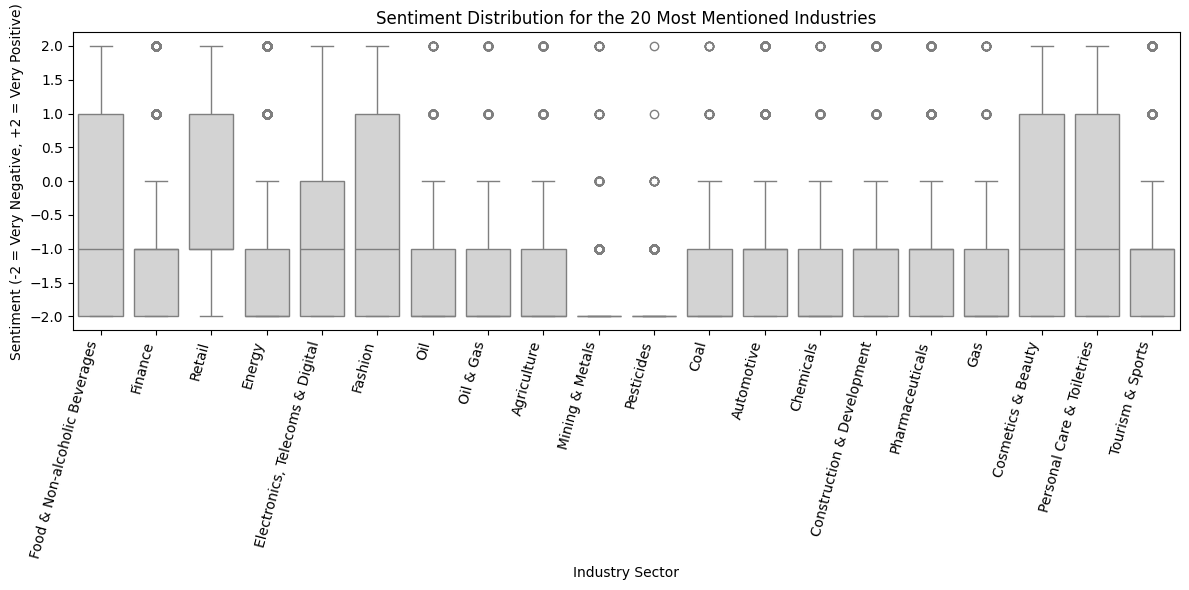

In [21]:
# Drop rows where industry is missing
valid_industries = combined.dropna(subset=["corp_industry_sector1"])

# Find 20 most mentioned industries (by number of campaign events)
top20_industries = (
    valid_industries["corp_industry_sector1"]
    .value_counts()
    .head(20)
    .index
)

# Subset the data
subset = valid_industries[valid_industries["corp_industry_sector1"].isin(top20_industries)]

# --- Boxplot (no color palette) ---
plt.figure(figsize=(12,6))
sns.boxplot(
    data=subset,
    x="corp_industry_sector1",
    y="sentiment",
    order=top20_industries,
    color="lightgray"
)
plt.title("Sentiment Distribution for the 20 Most Mentioned Industries")
plt.xlabel("Industry Sector")
plt.ylabel("Sentiment (-2 = Very Negative, +2 = Very Positive)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

- Across most industries, sentiment scores cluster toward the negative side, suggesting that **NGO campaigns and mentions are predominantly critical** in tone.
- Among others, the **Finance, Energy, Oil, Oil & Gas, Mining & Metals, Pesticides, and Coal sectors show particularly negative median sentiment**, indicating that these industries are frequent targets of campaigns highlighting environmental and ethical issues.
- A few industries, such as **Food & Non-alcoholic Beverages, Retail, Fashion, Cosmetics & Beauty, and Personal Care & Toiletries**, display **wider sentiment variability**, with some positive outliers — implying **mixed public or NGO perspectives**.
- The presence of **outliers with positive sentiment** in some sectors shows that while criticism dominates, there are still **instances of positive acknowledgment**.

In [22]:
# Clean industry field: convert blanks to NaN
combined["corp_industry_sector1"] = (
    combined["corp_industry_sector1"]
    .replace("", np.nan)
    .replace(" ", np.nan)
)

# Drop missing industries
valid_industries = combined.dropna(subset=["corp_industry_sector1"])

# --- Compute mean sentiment & count per industry ---
mean_stats = (
    valid_industries.groupby("corp_industry_sector1")["sentiment"]
    .agg(mean_sentiment="mean", count_records="count")
    .query("count_records >= 100")              # keep industries with enough data
    .sort_values("mean_sentiment", ascending=False)
)

# --- Display top/bottom 3 ---
top3_mean = mean_stats.head(3)
bottom3_mean = mean_stats.tail(3)

print("Top 3 Industries by Mean Sentiment (≥100 records):")
display(top3_mean)

print("\nBottom 3 Industries by Mean Sentiment (≥100 records):")
display(bottom3_mean)


Top 3 Industries by Mean Sentiment (≥100 records):


,mean_sentiment,count_records
corp_industry_sector1,,
Sportswear,-0.197452,157
Fashion,-0.301285,3734
Quick Service Restaurants,-0.339683,315



Bottom 3 Industries by Mean Sentiment (≥100 records):


,mean_sentiment,count_records
corp_industry_sector1,,
Pesticides,-1.788228,1563
Hydro and large dams,-1.806931,404
Hydro power,-1.833333,216


- The **Sportswear, Fashion, and Quick Service Restaurants** industries have the **highest (least negative) mean sentiment scores**, though all remain below zero. This suggests that while NGO discourse around these sectors is still mostly critical, there are some positive mentions, likely linked to **sustainability initiatives or corporate responsibility efforts**.
- In contrast, **the Pesticides, Hydro and large dams, and Hydro power** industries exhibit the **lowest mean sentiment scores**, indicating strongly negative NGO sentiment. These sectors are typically associated with **high environmental impact**.

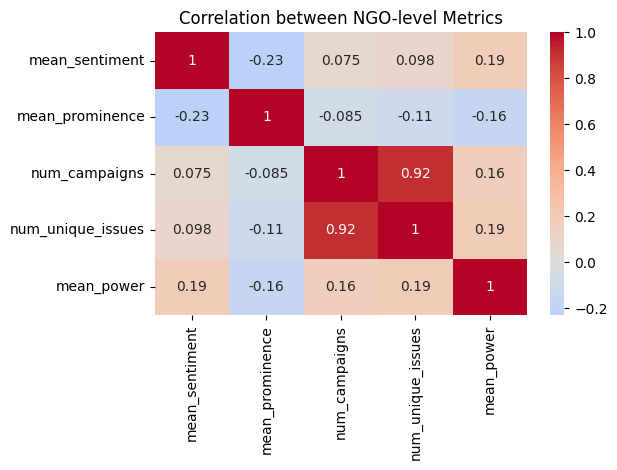

In [23]:
ngo_summary = (
    combined.groupby("ngo_name1")
    .agg(
        mean_sentiment=("sentiment", "mean"),
        mean_prominence=("prominence", "mean"),
        num_campaigns=("uid_archive", "nunique"),
        num_unique_issues=("issue_name1", "nunique"),
        mean_power=("ngo_power1", "mean")
    )
    .corr()
)

sns.heatmap(ngo_summary, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between NGO-level Metrics")
plt.tight_layout()
plt.show()

- NGOs that run **more campaigns** also tend to engage with **a wider range of unique issues**.
- **Higher media prominence** might coincide with **more critical sentiment or lower perceived power**.
- NGOs perceived as **more powerful** tend to have slightly **broader activity**.

### Industry Sector vs Sentiment

In [50]:
combined[['corp_industry_sector1', 'corp_industry_sector2', 'corp_industry_sector3']].nunique()

corp_industry_sector1    71
corp_industry_sector2    73
corp_industry_sector3    69
dtype: int64

In [51]:
sector_cols = ["corp_industry_sector1", "corp_industry_sector2", "corp_industry_sector3"]

# Melt to long form
sector_long = (
    combined.melt(
        id_vars=["sentiment"],
        value_vars=sector_cols,
        var_name="sector_source",
        value_name="sector"
    )
    .dropna(subset=["sector"])
)

# Clean the names
sector_long["sector"] = sector_long["sector"].str.strip().str.title()

In [52]:
print("Unique industry sectors:", sector_long["sector"].nunique())

Unique industry sectors: 69


In [53]:
sector_sentiment = sector_long.groupby("sector")["sentiment"].mean().sort_values()
print("Average sentiment by sector (most negative to most positive):")
print(sector_sentiment.head(10))
print(sector_sentiment.tail(10))


Average sentiment by sector (most negative to most positive):
sector
Pesticides                   -1.761771
Sodas & Juices               -1.750000
Hydro Power                  -1.743827
Hydro And Large Dams         -1.729560
Biotechnology                -1.695946
Mining & Metals              -1.683288
Nuclear                      -1.629630
Coal                         -1.616992
Geothermal                   -1.607143
Mining, Metals & Quarrying   -1.605550
Name: sentiment, dtype: float64
sector
Nanotechnology                                 -0.537037
Quick Service Restaurants                      -0.537002
Homecare (Eg. Detergents, Cleaning Products)   -0.478000
Personal Care & Toiletries                     -0.447205
Insurance                                      -0.423684
Retail                                         -0.401709
Textiles                                       -0.395763
Fashion                                        -0.319540
Household Hardware                            

Industries associated with **environmental or extractive activities** (such as energy, mining and oil) show the **most negative sentiment**, suggesting stronger NGO criticism in these areas.

In contrast, **service-oriented and financial sectors** display **more positive or neutral sentiment**, indicating comparatively cooperative or less confrontational engagement.

Overall, **NGO tone differs by sector** — critical toward high-impact industries and more favorable toward sectors linked to finance or sustainability initiatives.

## Refining dataset to only Banks / Financial Institutions

In [24]:
# Keep only rows where industry is exactly "Finance"
finance_df = combined[combined["corp_industry_sector1"] == "Finance"].copy()

print("Finance-only dataset shape:", finance_df.shape)
print(f"{finance_df.shape[0] / combined.shape[0] * 100:.2f}% of full dataset")

Finance-only dataset shape: (8347, 96)
11.42% of full dataset


In [147]:
unique_countries = pd.unique(
    finance_df[['company_parent_country']].values.ravel()
)

print(f'Target Countries: {unique_countries}')

Target Countries: ['Switzerland' 'Germany' 'Italy' 'Norway' 'Sweden' 'US' 'UK' 'Netherlands'
 'France' 'EU-Brussels' 'Australia' 'Spain' 'Japan' 'Belgium' 'China'
 'Philippines' 'South Korea' 'Ireland' 'Denmark' 'Canada' 'Luxembourg'
 'Austria' 'Mexico' 'Côte d’Ivoire' 'Chile' 'Brazil' 'Nigeria' 'Honduras'
 'Turkey' 'South Africa' 'Taiwan' 'Malaysia' 'Israel' 'Russia' 'India'
 'Portugal' 'Bermuda' 'Cambodia' 'Finland' 'Singapore' 'Venezuela'
 'Ukraine' 'Poland' 'United Arab Emirates' 'Bolivia' 'Vatican City'
 'Indonesia' 'Mozambique' 'Vietnam' 'Panama' 'Angola' 'USA'
 'Hong Kong SAR of China' 'New Zealand' 'Cayman Islands' 'Tanzania'
 'Kuwait' 'Colombia' 'Ghana' 'Qatar' 'Togo' 'Zambia' 'Kenya' 'Gabon'
 'Montenegro' 'Armenia' 'Bosnia and Herzegovina']


In [148]:
uk_us_eu = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden", "EU-Brussels"
] + ['US', 'USA', 'UK']

Saving the names of NGOs and Financial Institutions for further Web Scraping application:

In [149]:
ngo_cols = ["ngo_name1", "ngo_name2", "ngo_name3", "ngo_name4", "ngo_name5"]
target_cols = ['company_parent_country']
keep_cols = ["date", "isin_corporate_name_cleaned", 'company_parent_country', 'company_parent', "target_country1", "target_country2", "target_country3", "target_country4", "target_country5", "target_country6"] + ngo_cols

# countries of interest
countries_of_interest = uk_us_eu

# filter rows where ANY target_country column matches one of the countries_of_interest
mask = finance_df[target_cols].isin(countries_of_interest).any(axis=1)

# apply the mask and select relevant columns
subset_wide = (
    finance_df.loc[mask, keep_cols]
              .dropna(subset=ngo_cols, how="all")  # remove rows where all NGO columns are NaN
              .copy()
)

print(len(subset_wide))

6574


In [150]:
subset_wide.to_csv("events_date_ngos_company_wide.csv", index=False)

### NGOs and Target Companies Basic Analysis

In [34]:
df = finance_df

# Ensure date column is parsed
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year

# --- Company-level uniqueness ---
unique_companies_total = df["company"].nunique()
unique_companies_by_year = df.groupby("year")["company"].nunique()

# --- Company parent-level uniqueness ---
unique_parents_total = df["company_parent"].nunique()
unique_parents_by_year = df.groupby("year")["company_parent"].nunique()

# --- Target countries (across all 6 columns) ---
country_cols = [f"target_country{i}" for i in range(1, 7)]
unique_countries_total = pd.unique(df[country_cols].values.ravel('K'))
unique_countries_total = [c for c in unique_countries_total if pd.notna(c)]
n_unique_countries_total = len(unique_countries_total)

# --- Unique countries per company_parent (over whole period) ---
unique_countries_per_parent = (
    df.groupby("company_parent")[country_cols]
    .agg(lambda x: pd.unique(x.dropna()))
    .apply(lambda row: len(pd.unique([i for sub in row for i in (sub if isinstance(sub, (list, tuple, pd.Series, np.ndarray)) else [sub]) if pd.notna(i)])), axis=1)
)

# Sort and get top 10
top10_unique_countries_per_parent = unique_countries_per_parent.sort_values(ascending=False).head(10)

# --- NGO names (across all 6 columns) ---
ngo_cols = [f"ngo_name{i}" for i in range(1, 6)]
unique_ngos_total = pd.unique(df[ngo_cols].values.ravel('K'))
unique_ngos_total = [n for n in unique_ngos_total if pd.notna(n)]
n_unique_ngos_total = len(unique_ngos_total)

# --- Unique NGOs per company_parent ---
unique_ngos_per_parent = (
    df.groupby("company_parent")[ngo_cols]
    .agg(lambda x: pd.unique(x.dropna()))
    .apply(lambda row: len(pd.unique([
        i
        for sub in row
        for i in (sub if isinstance(sub, (list, tuple, pd.Series, np.ndarray)) else [sub])
        if pd.notna(i)
    ])), axis=1)
)

# Sort and get top 10
top10_ngos_per_parent = unique_ngos_per_parent.sort_values(ascending=False).head(10)
# Sort and get bottom 10
bottom10_ngos_per_parent = unique_ngos_per_parent.sort_values(ascending=True).head(10)

# --- Summary ---
print("=== Company-level ===")
print(f"Unique companies (total): {unique_companies_total}")
print("Unique companies by year:\n", unique_companies_by_year)

print("\n=== Company Parent ===")
print(f"Unique company_parents (total): {unique_parents_total}")
print("Unique company_parents by year:\n", unique_parents_by_year)

print("\n=== Countries ===")
print(f"Unique target countries (total): {n_unique_countries_total}")
print("Unique countries per company_parent (counts) for Top 10 parent companies with the greatest number of targeted countries:\n", top10_unique_countries_per_parent)

print("\n=== NGOs ===")
print(f"Unique NGOs (total): {n_unique_ngos_total}")
print("Unique NGOs per company_parent (counts) for Top 10 companies with the greatest number of unique NGOs:\n", top10_ngos_per_parent)
print("Unique NGOs per company_parent (counts) for Top 10 companies with the lowest number of unique NGOs:\n", bottom10_ngos_per_parent)


C:\Users\lasko\AppData\Local\Temp\ipykernel_33508\521759980.py:25: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  .apply(lambda row: len(pd.unique([i for sub in row for i in (sub if isinstance(sub, (list, tuple, pd.Series, np.ndarray)) else [sub]) if pd.notna(i)])), axis=1)


=== Company-level ===
Unique companies (total): 1188
Unique companies by year:
 year
2010    126
2011    219
2012    264
2013    300
2014    351
2015    352
2016    326
2017    443
2018    434
Name: company, dtype: int64

=== Company Parent ===
Unique company_parents (total): 1008
Unique company_parents by year:
 year
2010    114
2011    178
2012    239
2013    265
2014    322
2015    312
2016    284
2017    388
2018    377
Name: company_parent, dtype: int64

=== Countries ===
Unique target countries (total): 143
Unique countries per company_parent (counts) for Top 10 parent companies with the greatest number of targeted countries:
 company_parent
World Bank                      80
European Investment Bank EIB    51
EBRD                            44
ING                             44
HSBC                            43
Deutsche Bank                   43
BNP Paribas                     43
World Bank Group                43
Citigroup                       40
JP Morgan Chase              

C:\Users\lasko\AppData\Local\Temp\ipykernel_33508\521759980.py:41: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  .apply(lambda row: len(pd.unique([


At the company level, there are **1,188 unique financial institutions** recorded across the research period. The number of distinct companies **grows steadily over time**, beginning with just over one hundred in 2010 and more than tripling by 2017.

At the parent company level, there are **1,008 unique financial groups in total**. This slightly lower figure indicates that **many entities in the dataset are subsidiaries or affiliates belonging to larger corporate families**. The year-by-year trend follows a similar pattern to the company count.

When looking at geographic reach, the dataset covers **143 different target countries**, confirming a truly global scope. A few large institutions dominate this international footprint. **The World Bank** stands out as by far the most widely targeted finacial institution (80 countries). It is followed by major multilateral banks like the **European Investment Bank (EIB)** and **the European Bank for Reconstruction and Development (EBRD)**, as well as global commercial banks such as **HSBC, Deutsche Bank, BNP Paribas, and Citigroup**, each targeted in **more than 40 countries**.

In total, **1,075 unique NGOs are identified**. **The World Bank** leads, having been **targeted with 198 distinct NGOs**, which underscores its centrality in global finance. Other leading institutions, including **BNP Paribas, HSBC, Deutsche Bank, JP Morgan Chase, and Bank of America**, are typically targeted by a hundred each. This suggests that the largest international banks have increasingly engaged with civil society organizations, whether through **advocacy or conflict**, reflecting the rising importance of sustainability, human rights and environmental accountability in finance.

### Most targeted financial institutions

In [25]:
top_finance_companies = finance_df["company_parent"].value_counts().head(15)
display(top_finance_companies.to_frame(name="num_events"))

,num_events
company_parent,
World Bank,298
HSBC,247
BNP Paribas,228
Deutsche Bank,207
JP Morgan Chase,186
Bank of America,179
Barclays Bank,172
RBS Group,169
ING,169


The Top 5 most frequently mentioned financial institutions are:
- World Bank
- HSBC
- BNP Paribas
- Deutsche Bank
- JP Morgan Chase

This suggests that these organizations are **central targets of NGO advocacy**, likely due to their **global influence, investment reach and involvement in high-impact financial activities**.

### Issues by sentiment

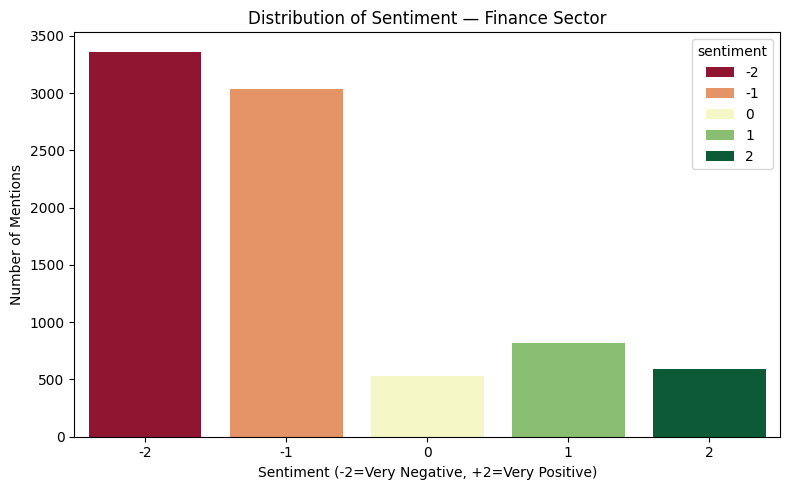

Average Sentiment (Finance Sector): -0.93


In [26]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=finance_df,
    x="sentiment",
    hue="sentiment",
    palette="RdYlGn")
plt.title("Distribution of Sentiment — Finance Sector")
plt.xlabel("Sentiment (-2=Very Negative, +2=Very Positive)")
plt.ylabel("Number of Mentions")
plt.tight_layout()
plt.show()

print("Average Sentiment (Finance Sector):", finance_df["sentiment"].mean().round(2))

- The **majority of mentions fall under very negative and negative** categories, together accounting for over two-thirds of all observations, suggesting that the finance sector is frequently associated with negative perceptions.
- Neutral and positive sentiments are relatively rare, indicating that **NGOs predominantly express criticism or concern toward financial institutions**.

### Countries by issues with percentage of total

In [27]:
# Top 15 active countries by event count
active_countries = (
    finance_df["active_country1"]
    .value_counts()
    .head(15)
    .to_frame(name="num_events")
)

# Add percentage of total
total_events = finance_df["active_country1"].notna().sum()
active_countries["percent_of_total"] = (
    active_countries["num_events"] / total_events * 100
).round(2)

display(active_countries)

,num_events,percent_of_total
active_country1,,
UK,1278,15.31
USA,1069,12.81
US,999,11.97
Netherlands,785,9.40
France,475,5.69
Germany,450,5.39
Spain,324,3.88
Australia,280,3.35
Belgium,276,3.31


Similar insights can be derived from the dataset for financial institutions only:
- **UK accounts for the largest share** of NGO actions, suggesting it is a **major hub for NGO-led campaign activity**.
- USA represents nearly one-quarter of all NGO activity, underscoring the **strong presence of campaigns in the United States**.
- Netherlands, France and Germany also rank highly, reflecting **significant NGO engagement across Western Europe**.

Overall, **NGO activity is concentrated in developed economies**, where many major financial institutions and policy centers are based.

### Over time

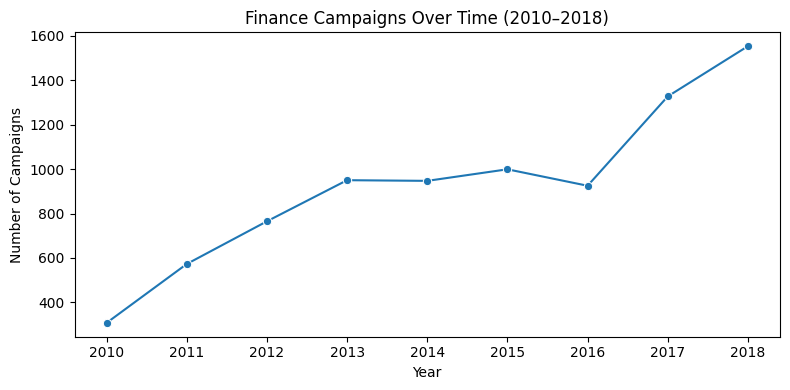

In [28]:
finance_df["year"] = pd.to_datetime(finance_df["date"], errors="coerce").dt.year
finance_trend = finance_df["year"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.lineplot(x=finance_trend.index, y=finance_trend.values, marker="o")
plt.title("Finance Campaigns Over Time (2010–2018)")
plt.xlabel("Year")
plt.ylabel("Number of Campaigns")
plt.tight_layout()
plt.show()


- NGO activity in the finance sector has **increased steadily over time**
- **From 2016 onward, campaign activity accelerated sharply**, suggesting NGO mobilization possibly in response to major financial or environmental policy developments.

Overall, the trend highlights **a long-term expansion of NGO engagement with financial institutions**, signaling the **sector’s growing importance in advocacy and accountability movements**.

### Top issues

In [29]:
finance_issues = (
    pd.concat([
        finance_df["issue_name1"],
        finance_df["issue_name2"],
        finance_df["issue_name3"]
    ])
    .value_counts()
    .head(20)
)
display(finance_issues.to_frame(name="count"))

,count
,6457
"Financial institutions & carbon, divestment",2146
CSR/ESG standards for financial institutions,1109
Financial institutions & consumer protection,794
Financial institutions & customer service,483
Regulation of financial institutions,454
Ethical investing/SRI,423
Financial institutions funding arms industry,415
"Tax havens, avoidance & financial transparency",405
Oil and gas pipelines,365


NGO campaigns targeting the finance sector focus on a **broad range of issues**, with the majority centered on general financial institution practices.

- The most frequently raised topics include **climate and divestment concerns**, particularly regarding the role of financial institutions in funding carbon-intensive industries.
- This is followed by strong attention to **CSR and ESG standards**, reflecting ongoing pressure on banks and investors to improve transparency, ethical conduct and sustainability performance.
- Other areas of activism include **consumer protection, customer service quality and the regulation of financial institutions**, highlighting concerns about accountability and fairness in financial operations.

Overall, the data shows that NGO engagement with the finance sector is driven by **a combination of environmental, ethical and governance priorities**, with climate and sustainability emerging as the most prominent themes.

### See if any NGOs target any specific companies

In [30]:
ngo_cols = ["ngo_name1","ngo_name2","ngo_name3","ngo_name4","ngo_name5"]
company_col = "company_parent"

# normalize empties/placeholders to NaN so they drop cleanly
placeholders = {"", " ", "-", "None", "none", "NA", "N/A", "nan", "NaN"}
finance_clean = finance_df.copy()
for c in ngo_cols:
    finance_clean[c] = (finance_clean[c].astype(str).str.strip()
                        .where(~finance_clean[c].astype(str).str.strip().isin(placeholders)))

# long format: (company, ngo)
ngo_company_pairs = (
    finance_clean
      .melt(id_vars=company_col, value_vars=ngo_cols, value_name="ngo_name")
      .dropna(subset=["ngo_name", company_col])
)

# counts per NGO–company pair
pair_counts = (
    ngo_company_pairs
      .groupby(["ngo_name", company_col])
      .size().reset_index(name="num_campaigns")
      .sort_values("num_campaigns", ascending=False)
)

# show strongest pairings
pair_counts.head(10)

,ngo_name,company_parent,num_campaigns
421,Amis de la Terre France / FoE France,BNP Paribas,63
5158,Rainforest Action Network RAN,Bank of America,57
476,Amis de la Terre France / FoE France,Societe Generale,55
1010,CEE Bankwatch Network,EBRD,53
1012,CEE Bankwatch Network,European Investment Bank EIB,45
6683,Which? (UK Consumers Association),HSBC,43
436,Amis de la Terre France / FoE France,Credit Agricole,41
6703,Which? (UK Consumers Association),RBS Group,41
6691,Which? (UK Consumers Association),Lloyds Banking Group plc,40
2028,Eerlijke Bankwijzer / Fair Bank Guide,SRH (formerly SNS Reaal),37


The table highlights NGOs that most frequently engage with or target specific financial institutions through campaigns.

- **Amis de la Terre France / Friends of the Earth France** emerges as **one of the most active NGOs**, consistently appearing across multiple major **French banks**— BNP Paribas, Société Générale and Crédit Agricole — indicating a **strong, sustained national advocacy** focus on French financial actors.
- **Rainforest Action Network (RAN) and CEE Bankwatch Network** also stand out, with concentrated campaigns toward large international banks such as Bank of America, EBRD, and the European Investment Bank (EIB).
- **Which? (UK Consumers Association)** shows **regionally concentrated efforts in the UK**.

### Most frequent issues

In [31]:
issue_cols = ["issue_name1", "issue_name2", "issue_name3"]

# Reshape to long format (company–issue pairs)
company_issue_pairs = (
    finance_df
      .melt(
          id_vars="company_parent",
          value_vars=issue_cols,
          value_name="issue_name"
      )
      .dropna(subset=["company_parent", "issue_name"])
)

# Count number of unique issues per company
unique_issue_counts = (
    company_issue_pairs
      .groupby("company_parent")["issue_name"]
      .nunique()
      .reset_index(name="num_unique_issues")
)

# Count issue frequency per company
issue_freq = (
    company_issue_pairs
      .groupby(["company_parent", "issue_name"])
      .size()
      .reset_index(name="num_mentions")
)

# Get top 3 issues per company (join into one text string)
top_issues = (
    issue_freq
      .sort_values(["company_parent", "num_mentions"], ascending=[True, False])
      .groupby("company_parent")
      .head(3)
      .groupby("company_parent")["issue_name"]
      .apply(lambda x: ", ".join(x))
      .reset_index(name="top_issues")
)

# Merge the summaries
summary = (
    unique_issue_counts
      .merge(top_issues, on="company_parent", how="left")
      .sort_values("num_unique_issues", ascending=False)
)

display(summary.head(5))


,company_parent,num_unique_issues,top_issues
993,World Bank,119,", World Bank, IMF & financial MLAs, Financial institutions & carbon, divestment"
468,HSBC,119,", Financial institutions & carbon, divestment, Financial institutions & customer service"
106,BNP Paribas,103,", Financial institutions & carbon, divestment, Tax havens, avoidance & financial transparency"
527,JP Morgan Chase,97,", Financial institutions & carbon, divestment, Regulation of financial institutions"
492,ING,93,", Financial institutions & carbon, divestment, CSR/ESG standards for financial institutions"


- Both the **World Bank and HSBC** top the list, each linked to 119 distinct issues, reflecting their central position in global finance and their broad exposure to NGO scrutiny. Their leading topics — notably **“Financial institutions & carbon, divestment”** and **“IMF & financial MLAs”** for the World Bank, and **“Customer service”** for HSBC — show a mix of **environmental accountability and operational concerns.**
- BNP Paribas is strongly associated with **carbon divestment and financial transparency** debates.
- JP Morgan Chase shows similar focus on **climate-related and regulatory issues**, underscoring transatlantic consistency in NGO priorities.
- ING aligns with recurring themes around **carbon divestment and ESG standards**, illustrating the growing expectation for sustainability integration within European finance.

Overall, the data suggests that NGOs engage the largest banks and development institutions on a wide spectrum of **environmental, governance and transparency issues**, with climate and divestment concerns emerging as a unifying theme.

### Relationship between Prominence, Sentiment and Partnership

In [38]:
corr_df = finance_df[["prominence", "sentiment", "partnership"]].copy()

# Drop rows with missing values to ensure clean correlation
corr_df = corr_df.dropna()

# Compute Pearson correlations
corr_matrix = corr_df.corr(method='pearson')
print("Pearson Correlation Matrix:")
print(corr_matrix)

# Extract the specific correlations you’re interested in
corr_prom_sent = corr_matrix.loc["prominence", "sentiment"]
corr_part_prom = corr_matrix.loc["partnership", "prominence"]
corr_part_sent = corr_matrix.loc["partnership", "sentiment"]

print("\nKey Relationships:")
print(f"Prominence ↔ Sentiment: {corr_prom_sent:.3f}")
print(f"Partnership ↔ Prominence: {corr_part_prom:.3f}")
print(f"Partnership ↔ Sentiment: {corr_part_sent:.3f}")

Pearson Correlation Matrix:
             prominence  sentiment  partnership
prominence     1.000000  -0.125931     0.024256
sentiment     -0.125931   1.000000     0.311085
partnership    0.024256   0.311085     1.000000

Key Relationships:
Prominence ↔ Sentiment: -0.126
Partnership ↔ Prominence: 0.024
Partnership ↔ Sentiment: 0.311


- Companies mentioned **more prominently** in NGO communications tend to be discussed in **a slightly more negative tone**.

- There is virtually **no relationship between collaboration and how prominently a company appears** in NGO messages.

- Companies engaged **in partnerships** with NGOs are associated with **more positive sentiment**. Partnerships appear to foster more favorable communication.

### Issue vs Sentiment

In [39]:
issue_cols = ["issue_name1", "issue_name2", "issue_name3"]

# Stack issue columns into a single column
issues_long = (
    finance_df.melt(
        id_vars=["sentiment"],
        value_vars=issue_cols,
        var_name="issue_source",
        value_name="issue"
    )
    .dropna(subset=["issue"])
)

issues_long["issue"] = issues_long["issue"].str.strip().str.lower()

In [40]:
# Average sentiment per issue
issue_sentiment = issues_long.groupby("issue")["sentiment"].mean().sort_values()

print("Average sentiment by issue:")
print(issue_sentiment.head(10))  # most negative
print(issue_sentiment.tail(10))  # most positive


Average sentiment by issue:
issue
road haulage - very large vehicles    -2.0
aviation - airport development        -2.0
slavery, child labor in agriculture   -2.0
slavery and child labor               -2.0
oil and gas drilling on land          -2.0
access to water, privatization        -2.0
oil & gas industry regulation         -2.0
mining - worker safety                -2.0
natural gas as low carbon fuel        -2.0
oil & gas drilling - deepwater        -2.0
Name: sentiment, dtype: float64
issue
energy efficiency                               2.0
phosphate run-off & eutrophication              2.0
plastics and chemical leaching                  2.0
volatile aromatic chemicals vocs                2.0
chemicals in the environment                    2.0
chemicals & plastic in drinking water           2.0
bullfighting and rodeo                          2.0
building integrity against natural disasters    2.0
untreated sewage disposal by municipalities     2.0
styrofoam containers (single u

Issues with the **most negative sentiment** tend to involve **controversial or high-impact areas**, where NGOs are more likely to criticize corporate behavior or demand accountability. These may include themes such as **environmental harm, human rights violations, or financial misconduct.**

In contrast, the **most positive sentiment** is associated with **collaborative or solution-oriented issues**, such as **sustainability initiatives, community development or climate finance**, where NGOs and companies often share aligned goals.

### NGO Power vs Sentiment

In [44]:
power_cols = ["ngo_power1", "ngo_power2", "ngo_power3", "ngo_power4", "ngo_power5"]
df_corr = finance_df[power_cols + ["sentiment"]].copy()

# Combine NGO power columns into a single value per observation (e.g., mean)
df_corr["avg_ngo_power"] = df_corr[power_cols].mean(axis=1)

# Drop missing values
df_corr = df_corr.dropna(subset=["avg_ngo_power", "sentiment"])

# Compute correlation
corr_value = df_corr["avg_ngo_power"].corr(df_corr["sentiment"], method="pearson")
print(f"Pearson correlation between NGO Power (average) and Sentiment: {corr_value:.3f}")

Pearson correlation between NGO Power (average) and Sentiment: 0.017


The correlation between average NGO power and sentiment is very weak (r = 0.02), indicating **no meaningful linear relationship** between the two.

This suggests that the **tone of NGO communication toward companies is largely independent of the organization’s influence or power**.
Powerful NGOs are not systematically more positive or more critical in their messaging than smaller ones. Instead, sentiment appears to be driven by issue context or specific corporate behavior, rather than by the NGO’s size or prominence.